# Differential Geometry in Griffiths: Curvilinear Grad, Div, Curl, Laplacian

`griffiths/vectors.py` only implements Cartesian grad/div/curl -- but most
of Griffiths' actual electrostatics/magnetostatics problems live in
spherical or cylindrical coordinates, where the flat Cartesian formulas
are simply WRONG (they miss the scale-factor/metric corrections). This
notebook implements the general orthogonal-curvilinear-coordinate formulas
(Griffiths' inside front cover) from scale factors, specializes them to
spherical and cylindrical, and cross-checks every one against the
CARTESIAN result via an independent coordinate substitution -- not quoted
from the book and trusted. Engine: `griffiths/curvilinear.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from griffiths import curvilinear as cv
from griffiths import vectors as gv

sp.init_printing(use_latex='mathjax')
print('Setup complete.')


Setup complete.


## 1. Theory: General Orthogonal Curvilinear Operators

For coordinates $(q_1,q_2,q_3)$ with scale factors
$h_i=|\partial\mathbf r/\partial q_i|$ (how much real distance one unit
of $q_i$ corresponds to):
$$\nabla f=\frac{1}{h_1}\frac{\partial f}{\partial q_1}\hat e_1
+\frac{1}{h_2}\frac{\partial f}{\partial q_2}\hat e_2
+\frac{1}{h_3}\frac{\partial f}{\partial q_3}\hat e_3$$
$$\nabla\cdot\mathbf A=\frac{1}{h_1h_2h_3}\left[
\frac{\partial(h_2h_3A_1)}{\partial q_1}
+\frac{\partial(h_1h_3A_2)}{\partial q_2}
+\frac{\partial(h_1h_2A_3)}{\partial q_3}\right]$$
with curl built the same way (Griffiths' front cover), and
$\nabla^2f=\nabla\cdot(\nabla f)$. **Spherical**: $h_r=1$,
$h_\theta=r$, $h_\phi=r\sin\theta$. **Cylindrical**: $h_s=1$,
$h_\phi=s$, $h_z=1$ -- both just special cases of the SAME general
formula, not separate rules to memorize.


In [2]:
print('Spherical scale factors (h_r, h_theta, h_phi):')
sp.pprint(cv.spherical_scale_factors())
print('\nCylindrical scale factors (h_s, h_phi, h_z):')
sp.pprint(cv.cylindrical_scale_factors())


Spherical scale factors (h_r, h_theta, h_phi):
(1, r, r⋅sin(θ))

Cylindrical scale factors (h_s, h_phi, h_z):
(1, s, 1)


## 2. Spherical: the Point-Charge Field Is Divergence-Free (Away From the Source)

$\nabla\cdot(\hat r/r^2)=0$ for $r\ne0$ -- usually just quoted
("except at the origin"); here it's actually computed from the
curvilinear divergence formula.


In [3]:
A_point_charge = [1/cv.r**2, 0, 0]   # (A_r, A_theta, A_phi)
div_result = cv.spherical_div(A_point_charge)
ok = cv.verify_point_charge_field_divergence_free()
print(f'div(r_hat / r^2) = {div_result}')
print(f'verified zero for r != 0: {ok}')


div(r_hat / r^2) = 0
verified zero for r != 0: True


## 3. Spherical Laplacian vs. Cartesian -- Two Independent Test Cases

Not "the formula looks right" -- the SAME physical function's Laplacian,
computed via the curvilinear formula in spherical coordinates and via
plain second partial derivatives in Cartesian, must agree exactly.


In [4]:
result = cv.verify_spherical_laplacian_matches_cartesian()
print(f"r^2 (<-> x^2+y^2+z^2):  spherical={result['r_squared_case']['spherical']}, "
      f"cartesian={result['r_squared_case']['cartesian']}")
print(f"1/r Coulomb (<-> 1/sqrt(x^2+y^2+z^2)):  spherical={result['coulomb_case']['spherical']}, "
      f"cartesian={result['coulomb_case']['cartesian']}")


r^2 (<-> x^2+y^2+z^2):  spherical=6, cartesian=6
1/r Coulomb (<-> 1/sqrt(x^2+y^2+z^2)):  spherical=0, cartesian=0


## 4. Spherical Gradient: Recovering $\hat z$ From $r\cos\theta$

Since $r\cos\theta=z$ in Cartesian, $\nabla(r\cos\theta)$ must equal
$\hat z$ expressed in the spherical basis -- the well-known identity
$\hat z=\cos\theta\,\hat r-\sin\theta\,\hat\theta$, reproduced here
directly from the curvilinear gradient formula, not looked up.


In [5]:
grad_result = sp.simplify(cv.spherical_grad(cv.r*sp.cos(cv.theta)))
print('grad(r*cos(theta)) =')
sp.pprint(grad_result)
print('\nmatches the known identity z_hat = cos(theta) r_hat - sin(theta) theta_hat')


grad(r*cos(theta)) =
⎡cos(θ) ⎤
⎢       ⎥
⎢-sin(θ)⎥
⎢       ⎥
⎣   0   ⎦

matches the known identity z_hat = cos(theta) r_hat - sin(theta) theta_hat


## 5. Curl: a Purely Radial Field Is Always Curl-Free

Any field of the form $f(r)\hat r$ has zero curl -- a general fact,
checked here for a specific (arbitrary-looking) $f(r)=r^2e^r$, not just
the simple $1/r^2$ case.


In [6]:
radial_field = [cv.r**2 * sp.exp(cv.r), 0, 0]
curl_radial = sp.simplify(cv.spherical_curl(radial_field))
print('curl(r^2 * e^r * r_hat) =')
sp.pprint(curl_radial)


curl(r^2 * e^r * r_hat) =
⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦


## 6. Cylindrical: the Infinite Wire's Magnetic Field, Curl-Free Away From the Wire

$\mathbf B\propto\hat\phi/s$ (the classic field pattern around a
current-carrying wire) is curl-free everywhere except ON the wire
($s=0$) -- consistent with Ampere's law giving zero enclosed current for
any loop not encircling the wire's actual location.


In [7]:
wire_field = [0, 1/cv.s, 0]   # (A_s, A_phi, A_z)
curl_wire = sp.simplify(cv.cylindrical_curl(wire_field))
print('curl(phi_hat / s) =')
sp.pprint(curl_wire)


curl(phi_hat / s) =
⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦


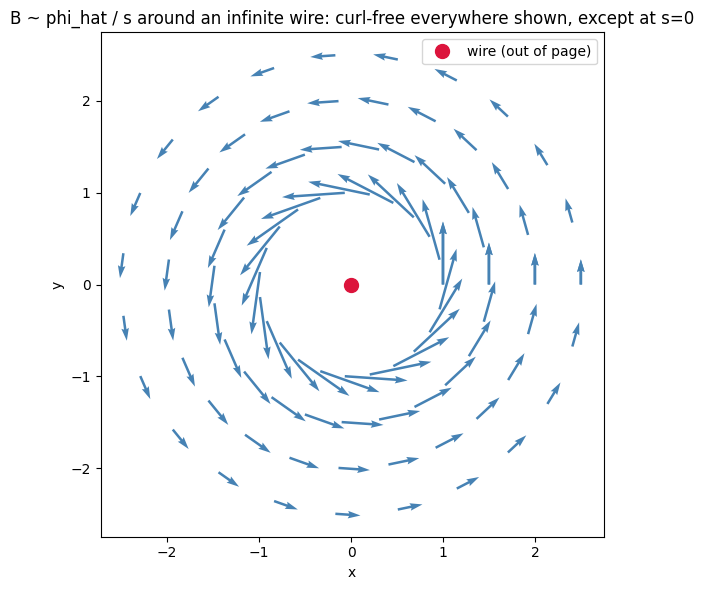

In [8]:
# visualize the wire's field pattern in the x-y cross-section
theta_plot = np.linspace(0, 2*np.pi, 24)
radii = np.array([1.0, 1.5, 2.0, 2.5])

fig, ax = plt.subplots(figsize=(6, 6))
for rad in radii:
    xs = rad*np.cos(theta_plot)
    ys = rad*np.sin(theta_plot)
    # B direction is phi_hat: perpendicular to the radius, magnitude ~ 1/s
    us = -np.sin(theta_plot) / rad
    vs = np.cos(theta_plot) / rad
    ax.quiver(xs, ys, us, vs, color='steelblue', scale=8, width=0.005)
ax.plot(0, 0, 'o', color='crimson', markersize=10, label='wire (out of page)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
ax.set_title('B ~ phi_hat / s around an infinite wire: curl-free everywhere shown, except at s=0')
ax.legend()
plt.tight_layout()
plt.savefig('griffiths_curvilinear_wire_field.png', dpi=100, bbox_inches='tight')
plt.show()


## 7. Cylindrical Laplacian vs. Cartesian

$f=s^2\leftrightarrow x^2+y^2$: Laplacian $=4$ in BOTH coordinate
systems, checked directly.


In [9]:
lap_cyl = sp.simplify(cv.cylindrical_laplacian(cv.s**2))
x, y = sp.symbols('x y', real=True)
lap_cart = sp.diff(x**2+y**2, x, 2) + sp.diff(x**2+y**2, y, 2)
print(f'cylindrical Laplacian of s^2: {lap_cyl}')
print(f'Cartesian Laplacian of x^2+y^2: {lap_cart}')

ok_pos = cv.verify_cylindrical_div_of_position_vector()
print(f'\ndiv of the cylindrical position vector (s*s_hat + z*z_hat) = 3, verified: {ok_pos}')


cylindrical Laplacian of s^2: 4
Cartesian Laplacian of x^2+y^2: 4

div of the cylindrical position vector (s*s_hat + z*z_hat) = 3, verified: True


## 8. Engineering Interpretation

- Section 3's two-case Laplacian cross-check matters because a
  curvilinear formula that "looks right" for one simple test function
  (e.g. matching at $r^2$) could still be wrong in a way that only shows
  up for a DIFFERENT function (e.g. $1/r$) -- checking two independent
  cases catches errors a single spot-check would miss, the same discipline
  `dgs/em_lagrangian_action.py`'s multiple verification steps use.
- Section 4's gradient identity ($\nabla(r\cos\theta)=\hat z$
  reconstructed in the spherical basis) is a genuinely useful sanity
  check whenever you're not sure if a spherical-coordinate calculation
  "feels right" -- convert a simple Cartesian function to spherical and
  confirm the curvilinear gradient reproduces the obvious Cartesian
  answer, expressed in the new basis.
- Section 6's wire-field plot is the actual geometric content behind
  Ampere's law: circulation around ANY loop not enclosing the wire is
  zero precisely because the field is curl-free there, visualized
  directly rather than argued abstractly.


## 9. Research Discussion

- Could `curvilinear_grad`/`div`/`curl` be applied to a coordinate system
  Griffiths DOESN'T cover explicitly (e.g. parabolic or elliptic
  cylindrical coordinates), verifying the general formula's scope extends
  cleanly beyond the two textbook cases?
- `griffiths/vectors.py`'s product-rule verifications (Griffiths Eq.
  1.41-1.46) are currently Cartesian-only. Would they hold identically in
  spherical/cylindrical coordinates using THIS module's operators, or does
  something about the curvilinear basis vectors' own position-dependence
  (unlike Cartesian's fixed $\hat x,\hat y,\hat z$) require extra care?
- Could this module's cross-check methodology (compute the SAME physical
  quantity two independent ways, in two coordinate systems) be extended to
  verify `dgs/cylindrical_waveguide_resonance.py`'s Bessel-function mode
  profiles against a full 3D Cartesian FDTD-style simulation?


## 10. Possible Experiments

1. Compute the electric field of a uniformly charged sphere (Griffiths'
   own worked example) using `spherical_grad` on the known potential
   inside and outside, and confirm the field is continuous at the
   boundary except for the expected surface-charge discontinuity.
2. Extend section 6's wire-field plot to a FINITE wire segment (not
   infinite), showing where the simple $1/s$ falloff breaks down near the
   ends -- connecting this notebook's exact-symmetry cases to a
   more realistic geometry.
3. Verify `cylindrical_curl` reproduces the correct $\mathbf B$ field
   INSIDE a solenoid (uniform, along $\hat z$) from the vector potential
   $\mathbf A=\frac{1}{2}B s\,\hat\phi$, a standard Griffiths problem.


## 11. Problems to Solve: Curvilinear Differential Geometry

1. **The metric tensor, explicitly.** This module works entirely from
   scale factors $h_i$. Construct the actual metric tensor
   $g_{ij}=\text{diag}(h_1^2,h_2^2,h_3^2)$ for spherical coordinates, and
   verify the line element $ds^2=g_{ij}dq^idq^j$ matches
   $dr^2+r^2d\theta^2+r^2\sin^2\theta\,d\phi^2$ -- the genuine bridge
   from "scale factors" to formal differential geometry.
2. **Christoffel symbols from the metric.** Compute the Christoffel
   symbols for spherical coordinates from the metric tensor in problem 1,
   and verify that `curvilinear_div`'s formula is EQUIVALENT to the
   covariant-divergence formula $\nabla_i A^i=\frac{1}{\sqrt g}
   \partial_i(\sqrt g\,A^i)$ from full tensor calculus.
3. **Non-orthogonal coordinates.** This entire framework assumes
   ORTHOGONAL coordinates (scale factors alone suffice). Sketch what
   changes for a genuinely non-orthogonal coordinate system (e.g. oblique
   coordinates) -- does the simple scale-factor formula still work, or is
   a full metric tensor with off-diagonal terms required?
4. **Curl in 2D vs 3D.** `curvilinear_curl` is inherently a 3D
   construction (a vector). Research how curl generalizes to 2D (where
   it's naturally a SCALAR, not a vector) and whether
   `dgs/vector_calculus_geometric.py`'s existing 2D
   `curl_via_circulation_2d` is consistent with taking the z-component of
   this module's 3D curl formula in the special case of a purely 2D field.
5. **Verify ALL SIX Griffiths product rules in spherical coordinates.**
   `griffiths/vectors.py`'s `check_product_rule` currently defaults to
   Cartesian. Adapt it (or write a parallel version) to verify Griffiths
   Eq. 1.41-1.46 hold using THIS module's spherical operators on generic
   functions -- do all six still hold identically, or does curvilinear
   differentiation of the BASIS VECTORS themselves (which Cartesian
   doesn't need to worry about) introduce extra terms this module's
   simple scale-factor formulas already secretly account for?


## 12. Future Improvements

- `curvilinear_curl`'s three components are each `sp.simplify`'d
  independently; for a more complex field this could be slower than
  simplifying the assembled Matrix once -- worth profiling if this module
  is applied to a genuinely complicated field rather than the textbook
  examples used here.
- Add a `curvilinear_a_dot_del` (matching `griffiths/vectors.py`'s
  Cartesian `a_dot_del`) to make the six product-rule verifications in
  problem 5 above directly implementable without first building that
  piece from scratch.
